# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Srilaya30/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

repo_root = Path("/content/flyrank-ml-internship")

if not repo_root.exists():
    !git clone -q https://github.com/Srilaya30/flyrank-ml-internship.git

data_path = repo_root / "data" / "raw" / "content_refresh_anonymized.csv"

df = pd.read_csv(data_path)

df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Dataset shape:", df.shape)
print("Dataset loaded successfully.")

Dataset shape: (30000, 45)
Dataset loaded successfully.


In [2]:
feature_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

X = df[feature_cols].copy()
y = df["is_declining_label"].copy()

print("Number of features:", len(feature_cols))

Number of features: 29


In [3]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=df["client_id"])
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

train_clients = set(df.iloc[train_idx]["client_id"])
test_clients = set(df.iloc[test_idx]["client_id"])

print("Client overlap:", len(train_clients & test_clients))

Training rows: 23837
Testing rows: 6163
Client overlap: 0


In [4]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully.")

Model trained successfully.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

I will use the model's predicted probability of decline to prioritize pages for human review. A higher score means the model gives a higher probability to the declining class. The score is used for ranking and decision support, not as proof that a page will decline or that a particular action will improve performance.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [6]:
action_queue = df.iloc[test_idx].copy()

action_queue["decline_score"] = y_prob

action_queue["priority_rank"] = (
    action_queue["decline_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

In [7]:
def get_reason_code(row):
    reasons = []

    if row["days_since_last_update"] > df["days_since_last_update"].median():
        reasons.append("STALENESS")

    if row["content_age_days"] > df["content_age_days"].median():
        reasons.append("OLDER_CONTENT")

    if row["impressions_last_30d"] < row["impressions_prev_30d"]:
        reasons.append("RECENT_IMPRESSION_DECLINE")

    if row["avg_position"] > df["avg_position"].median():
        reasons.append("WEAKER_POSITION")

    if row["ctr"] < df["ctr"].median():
        reasons.append("LOWER_CTR")

    if not reasons:
        reasons.append("MODEL_SIGNAL")

    return ", ".join(reasons[:3])

action_queue["reason_code"] = action_queue.apply(
    get_reason_code,
    axis=1
)

In [8]:
def recommend_action(row):
    if row["decline_score"] >= 0.75:
        return "Prioritize review"
    elif row["decline_score"] >= 0.50:
        return "Review when capacity allows"
    else:
        return "Monitor"

action_queue["recommended_action"] = action_queue.apply(
    recommend_action,
    axis=1
)

In [9]:
ranked_actions = action_queue.sort_values(
    "decline_score",
    ascending=False
)[
    [
        "priority_rank",
        "content_id",
        "decline_score",
        "reason_code",
        "recommended_action"
    ]
]

print(ranked_actions.head(20).to_string(index=False))

 priority_rank           content_id  decline_score                                           reason_code recommended_action
             3 content_9e8671965fff          0.995                             RECENT_IMPRESSION_DECLINE  Prioritize review
             2 content_d028d97a0f72          0.995                  RECENT_IMPRESSION_DECLINE, LOWER_CTR  Prioritize review
             1 content_eb58f272b967          0.995                  RECENT_IMPRESSION_DECLINE, LOWER_CTR  Prioritize review
             5 content_ed65b2e130c6          0.985                  RECENT_IMPRESSION_DECLINE, LOWER_CTR  Prioritize review
             6 content_06b02c9b01a1          0.985                  RECENT_IMPRESSION_DECLINE, LOWER_CTR  Prioritize review
             4 content_eb3b2c3bbc34          0.985                  RECENT_IMPRESSION_DECLINE, LOWER_CTR  Prioritize review
            10 content_b23d650634c6          0.980                  RECENT_IMPRESSION_DECLINE, LOWER_CTR  Prioritize review
        

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: The action queue is intended for content teams to prioritize which pages should be reviewed first. The model score and reason codes provide decision support for deciding where human attention may be useful.

Limits: The score does not prove that a page will decline, identify the cause of a decline, or guarantee that a particular content action will improve performance. The model was evaluated on this dataset using a client-grouped split, so performance may differ on future data or other datasets.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human review: Before acting on a recommendation, a person should check the page's current content, search intent, recent updates, traffic context, business importance, and whether the recommendation makes sense for the specific page.

No-go list: The system must not automatically publish content changes, delete pages, redirect URLs, change metadata, change client strategy, or claim that a refresh caused an improvement. The model is only used to prioritize pages for human review.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

I would monitor the model's measured Precision@20 and the quality of the highest-ranked recommendations over time. A retraining or review trigger would be needed if performance falls materially from the validation result, if the data distribution changes substantially, or if reviewers repeatedly find that high-ranked pages are not useful review candidates.

I would also review the feature distributions and the proportion of declining pages periodically. If the underlying content or traffic patterns change, the existing ranking may no longer represent current conditions.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [11]:
def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1][:k]
    return np.mean(np.asarray(y_true)[order])

print("Precision@20 function ready.")

Precision@20 function ready.


In [12]:
print("Monitoring baseline metrics")
print("Validation Precision@20:", round(
    precision_at_k(y_test.to_numpy(), y_prob, 20), 4
))

print("Declining rate in test set:",
      round(y_test.mean(), 4))

print("Test rows:", len(y_test))

Monitoring baseline metrics
Validation Precision@20: 1.0
Declining rate in test set: 0.511
Test rows: 6163


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [13]:
output_dir = repo_root / "work" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

queue_path = output_dir / "content_action_queue.csv"

ranked_actions.to_csv(
    queue_path,
    index=False
)

print("Saved:", queue_path)


Saved: /content/flyrank-ml-internship/work/outputs/content_action_queue.csv


In [14]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importance_path = output_dir / "feature_importance.csv"

feature_importance.to_csv(
    importance_path,
    header=["importance"]
)

print("Saved:", importance_path)

Saved: /content/flyrank-ml-internship/work/outputs/feature_importance.csv


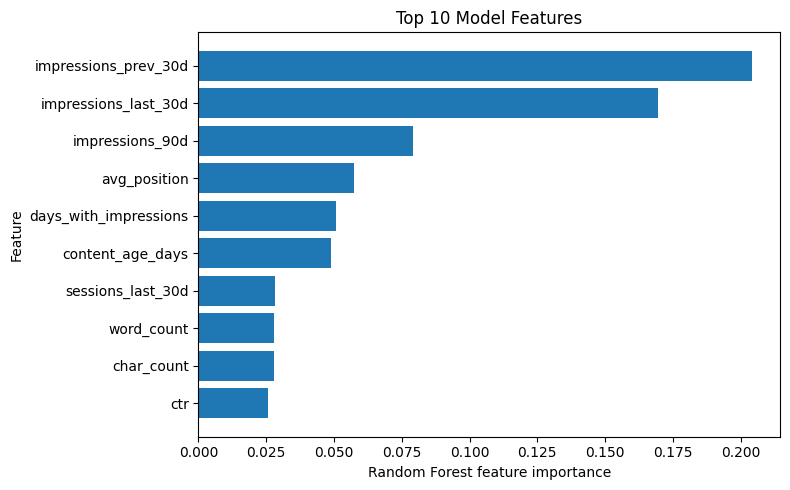

Saved: /content/flyrank-ml-internship/work/outputs/top_feature_importance.png


In [15]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(
    top_features.index,
    top_features.values
)
plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Model Features")
plt.tight_layout()

figure_path = output_dir / "top_feature_importance.png"

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [16]:
print("ML-10 FINAL CHECK")
print("-----------------")
print("Ranked actions:", len(ranked_actions))
print(
    "Reason codes present:",
    ranked_actions["reason_code"].notna().all()
)
print(
    "Recommended actions present:",
    ranked_actions["recommended_action"].notna().all()
)
print(
    "Client overlap:",
    len(train_clients & test_clients)
)
print(
    "Queue exported:",
    queue_path.exists()
)
print(
    "Feature importance exported:",
    importance_path.exists()
)
print(
    "Figure exported:",
    figure_path.exists()
)

ML-10 FINAL CHECK
-----------------
Ranked actions: 6163
Reason codes present: True
Recommended actions present: True
Client overlap: 0
Queue exported: True
Feature importance exported: True
Figure exported: True
